# 🛒 Alfido Tech – Superstore Sales Performance Analysis
**Period:** January 2015 – December 2018  
**Dataset:** 9,800 transactions | 793 unique customers | 4 regions | 3 categories  
**Author:** Alfido Tech Analytics Team

---


In [1]:
#!pip install pandas numpy matplotlib 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────
PRIMARY, ACCENT, TEAL = "#1A237E", "#FF6F00", "#00838F"
GREEN, RED, LIGHT_BG  = "#2E7D32", "#C62828", "#F5F7FA"
plt.rcParams.update({'figure.facecolor': LIGHT_BG, 'axes.facecolor': LIGHT_BG,
                     'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False})
print("✅ Libraries loaded")


✅ Libraries loaded


## 1. Data Loading & Cleaning

In [2]:
# ── Load ───────────────────────────────────────────────────
df = pd.read_csv('superstore_final_dataset.csv', encoding='latin1')

# ── Parse dates ─────────────────────────────────────────────
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=False)
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'],  dayfirst=False)

# ── Feature engineering ──────────────────────────────────────
df['Month']       = df['Order_Date'].dt.to_period('M')
df['Quarter']     = df['Order_Date'].dt.to_period('Q')
df['Year']        = df['Order_Date'].dt.year
df['MonthNum']    = df['Order_Date'].dt.month
df['DaysToShip']  = (df['Ship_Date'] - df['Order_Date']).dt.days

# ── Deduplication ────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset=['Order_ID','Product_ID'], inplace=True)
print(f"Rows before dedup: {before:,} | After: {len(df):,} | Removed: {before - len(df)}")

# ── Quality report ───────────────────────────────────────────
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
print(f"\nDate range: {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}")
df.head(3)


Rows before dedup: 9,800 | After: 9,792 | Removed: 8

Missing values:
Postal_Code    11
dtype: int64

Date range: 2015-01-02 → 2018-12-30


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Product_ID,Category,Sub_Category,Product_Name,Sales,Month,Quarter,Year,MonthNum,DaysToShip
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017-08,2017Q3,2017,8,92
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017-08,2017Q3,2017,8,92
2,3,CA-2017-138688,2017-12-06,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2017-12,2017Q4,2017,12,-173


## 2. Key Performance Indicators

In [3]:
total_sales      = df['Sales'].sum()
total_orders     = df['Order_ID'].nunique()
aov              = total_sales / total_orders
unique_customers = df['Customer_ID'].nunique()
orders_per_cust  = total_orders / unique_customers
avg_days_ship    = df['DaysToShip'].mean()

kpis = {
    'Total Revenue':        f"${total_sales:,.0f}",
    'Total Orders':         f"{total_orders:,}",
    'Avg Order Value':      f"${aov:,.2f}",
    'Unique Customers':     f"{unique_customers:,}",
    'Orders / Customer':    f"{orders_per_cust:.1f}",
    'Avg Days to Ship':     f"{avg_days_ship:.1f} days",
}

print("=" * 45)
print("  📊  ALFIDO TECH — SUPERSTORE KPI SUMMARY")
print("=" * 45)
for k, v in kpis.items():
    print(f"  {k:<25} {v:>12}")
print("=" * 45)


  📊  ALFIDO TECH — SUPERSTORE KPI SUMMARY
  Total Revenue               $2,259,845
  Total Orders                     4,922
  Avg Order Value                $459.13
  Unique Customers                   793
  Orders / Customer                  6.2
  Avg Days to Ship              9.2 days


## 3. Revenue Trends

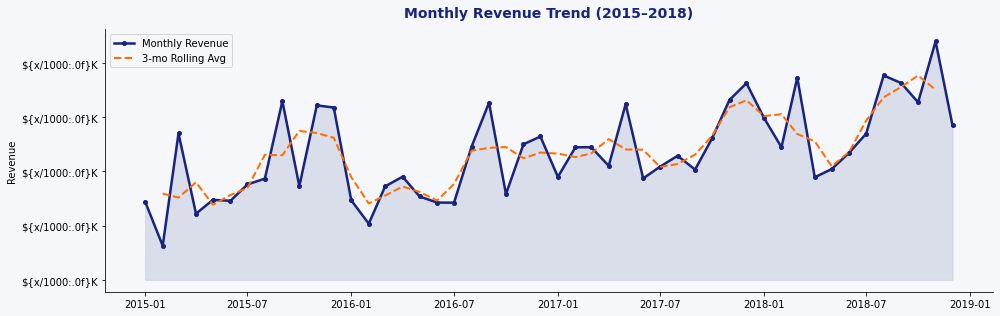


Year-over-Year Revenue:
  2015: $   479,575
  2016: $   459,346  (-4.2% YoY)
  2017: $   599,519  (+30.5% YoY)
  2018: $   721,405  (+20.3% YoY)


In [4]:
monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month_dt'] = monthly['Month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.fill_between(monthly['Month_dt'], monthly['Sales'], alpha=0.12, color=PRIMARY)
ax.plot(monthly['Month_dt'], monthly['Sales'], color=PRIMARY, lw=2.5, marker='o', ms=4, label='Monthly Revenue')
rolling = monthly['Sales'].rolling(3, center=True).mean()
ax.plot(monthly['Month_dt'], rolling, color=ACCENT, lw=2, ls='--', label='3-mo Rolling Avg')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${{x/1000:.0f}}K'))
ax.set_title('Monthly Revenue Trend (2015–2018)', fontsize=14, fontweight='bold', color=PRIMARY, pad=12)
ax.set_ylabel('Revenue'); ax.legend()
plt.tight_layout(); plt.show()

# YoY summary
print("\nYear-over-Year Revenue:")
yoy = df.groupby('Year')['Sales'].sum()
for yr, val in yoy.items():
    change = ""
    if yr > yoy.index[0]:
        pct = (val - yoy[yr-1]) / yoy[yr-1] * 100
        change = f"  ({'+' if pct>=0 else ''}{pct:.1f}% YoY)"
    print(f"  {yr}: ${val:>10,.0f}{change}")


## 4. Regional Performance

         Revenue  Orders  Customers  AOV
Region                                  
West    $710,117    1587        681 $226
East    $668,644    1369        669 $240
Central $492,647    1156        626 $216
South   $388,437     810        509 $244


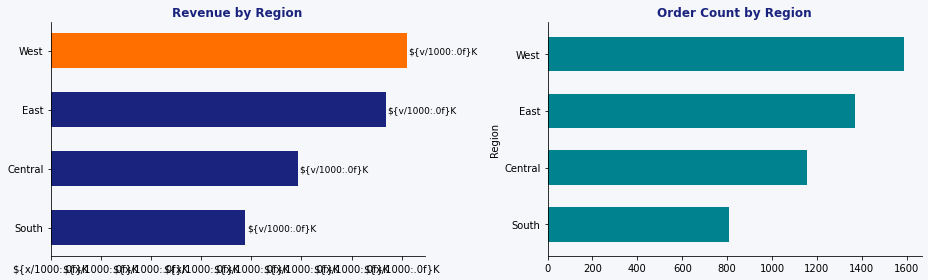

In [5]:
region = df.groupby('Region').agg(
    Revenue=('Sales','sum'),
    Orders=('Order_ID','nunique'),
    Customers=('Customer_ID','nunique'),
    AOV=('Sales','mean')
).sort_values('Revenue', ascending=False)

print(region.to_string(float_format='${:,.0f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rev = region['Revenue'].sort_values()
colors = [ACCENT if r==rev.idxmax() else PRIMARY for r in rev.index]
axes[0].barh(rev.index, rev.values, color=colors, height=0.6)
for i, v in enumerate(rev.values):
    axes[0].text(v+3000, i, f'${{v/1000:.0f}}K', va='center', fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${{x/1000:.0f}}K'))
axes[0].set_title('Revenue by Region', fontsize=12, fontweight='bold', color=PRIMARY)

region['Orders'].sort_values().plot(kind='barh', ax=axes[1], color=TEAL, width=0.6)
axes[1].set_title('Order Count by Region', fontsize=12, fontweight='bold', color=PRIMARY)
plt.tight_layout(); plt.show()


## 5. Category & Sub-Category Analysis

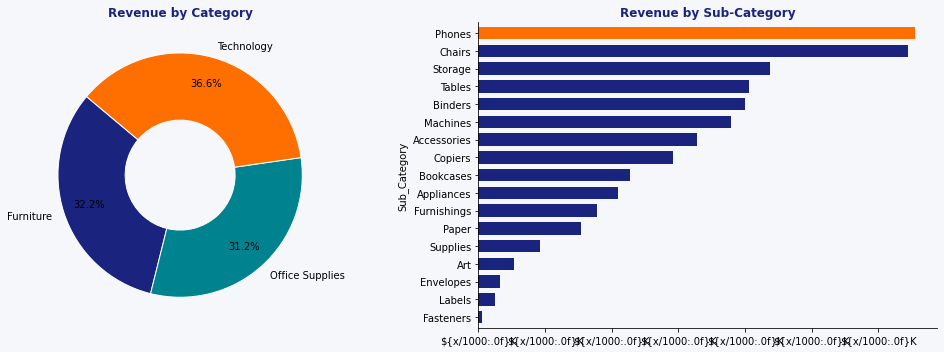


Top 3 Sub-Categories:
  Phones               $   327,782  (14.5% of total)
  Chairs               $   322,541  (14.3% of total)
  Storage              $   218,799  (9.7% of total)


In [6]:
cat   = df.groupby('Category')['Sales'].sum()
subcat = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(cat.values, labels=cat.index, autopct='%1.1f%%',
            colors=[PRIMARY, TEAL, ACCENT], startangle=140,
            wedgeprops=dict(width=0.55, edgecolor='white'), pctdistance=0.78)
axes[0].set_title('Revenue by Category', fontsize=12, fontweight='bold', color=PRIMARY)

colors_sub = [ACCENT if i==0 else PRIMARY for i in range(len(subcat))]
subcat.sort_values().plot(kind='barh', ax=axes[1], color=colors_sub[::-1], width=0.7)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${{x/1000:.0f}}K'))
axes[1].set_title('Revenue by Sub-Category', fontsize=12, fontweight='bold', color=PRIMARY)
plt.tight_layout(); plt.show()

print("\nTop 3 Sub-Categories:")
for sc, v in subcat.head(3).items():
    print(f"  {sc:<20} ${v:>10,.0f}  ({v/cat.sum()*100:.1f}% of total)")


## 6. Seasonality Analysis

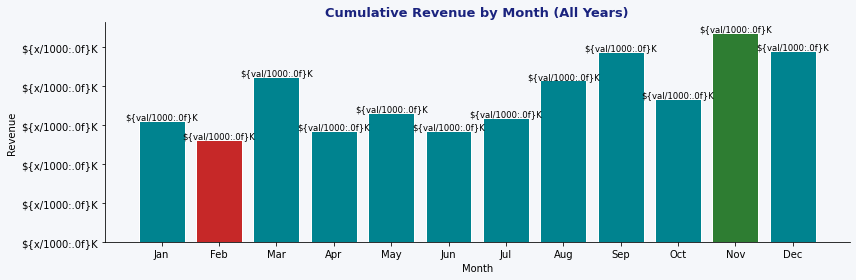

Peak month:   {monthly_avg.idxmax()} ($268,769)
Lowest month: {monthly_avg.idxmin()} ($131,153)
Seasonality ratio (peak/low): {monthly_avg.max()/monthly_avg.min():.1f}x


In [7]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['MonthName'] = df['Order_Date'].dt.strftime('%b')
monthly_avg = df.groupby('MonthName')['Sales'].sum()
# reorder
monthly_avg = monthly_avg.reindex(month_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(monthly_avg.index, monthly_avg.values,
              color=[RED if v==monthly_avg.min() else GREEN if v==monthly_avg.max() else TEAL 
                     for v in monthly_avg.values], edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${{x/1000:.0f}}K'))
ax.set_title('Cumulative Revenue by Month (All Years)', fontsize=13, fontweight='bold', color=PRIMARY)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue')
# annotations
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000, 
            f'${{val/1000:.0f}}K', ha='center', fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"Peak month:   {{monthly_avg.idxmax()}} (${monthly_avg.max():,.0f})")
print(f"Lowest month: {{monthly_avg.idxmin()}} (${monthly_avg.min():,.0f})")
print(f"Seasonality ratio (peak/low): {{monthly_avg.max()/monthly_avg.min():.1f}}x")


## 7. Product Performance

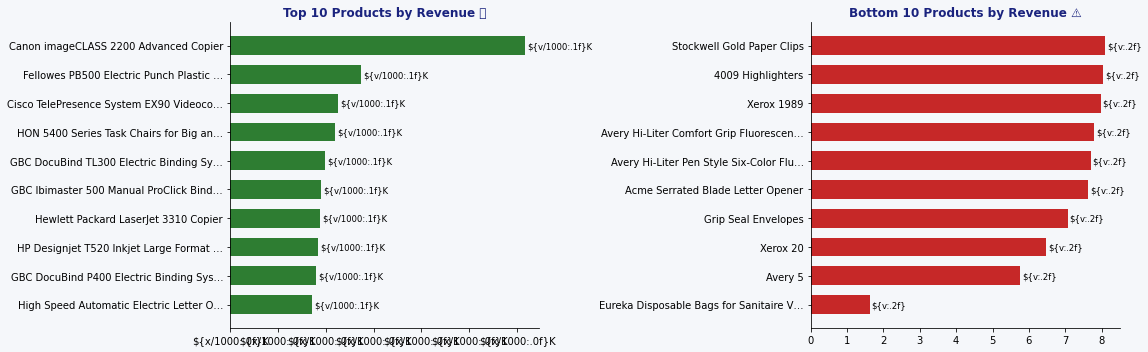

In [8]:
prod = df.groupby('Product_Name')['Sales'].sum()
top10 = prod.sort_values(ascending=False).head(10)
bot10 = prod.sort_values().head(10)

def shorten(name, n=38):
    return name if len(name)<=n else name[:n]+'…'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_lbl = [shorten(n) for n in top10.index[::-1]]
axes[0].barh(top_lbl, top10.values[::-1], color=GREEN, height=0.65)
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v+500, i, f'${{v/1000:.1f}}K', va='center', fontsize=8.5)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${{x/1000:.0f}}K'))
axes[0].set_title('Top 10 Products by Revenue ✅', fontsize=12, fontweight='bold', color=PRIMARY)

bot_lbl = [shorten(n) for n in bot10.index]
axes[1].barh(bot_lbl, bot10.values, color=RED, height=0.65)
for i, v in enumerate(bot10.values):
    axes[1].text(v+0.05, i, f'${{v:.2f}}', va='center', fontsize=8.5)
axes[1].set_title('Bottom 10 Products by Revenue ⚠️', fontsize=12, fontweight='bold', color=PRIMARY)
plt.tight_layout(); plt.show()


## 8. Customer Segments & Shipping

Segment Performance:
             Revenue  Orders      AOV
Segment                              
Consumer    ${:,.0f}    5099 ${:,.0f}
Corporate   ${:,.0f}    2952 ${:,.0f}
Home Office ${:,.0f}    1741 ${:,.0f}


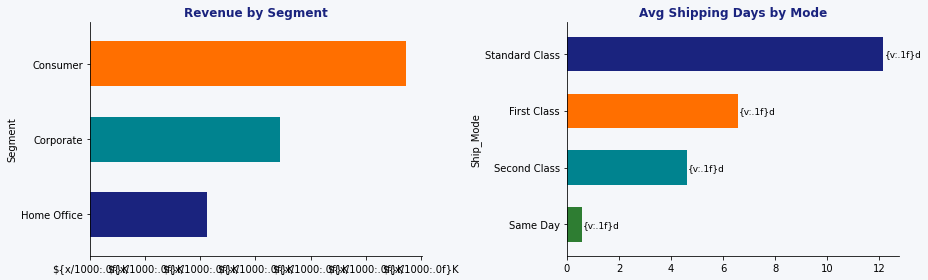

In [9]:
seg = df.groupby('Segment')['Sales'].agg(['sum','count','mean'])
seg.columns = ['Revenue','Orders','AOV']
print("Segment Performance:")
print(seg.to_string(float_format='${{:,.0f}}'.format))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
seg['Revenue'].sort_values().plot(kind='barh', ax=axes[0], color=[PRIMARY,TEAL,ACCENT], width=0.6)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${{x/1000:.0f}}K'))
axes[0].set_title('Revenue by Segment', fontsize=12, fontweight='bold', color=PRIMARY)

ship = df.groupby('Ship_Mode')['DaysToShip'].mean().sort_values()
ship.plot(kind='barh', ax=axes[1], color=[GREEN,TEAL,ACCENT,PRIMARY], width=0.6)
for i, v in enumerate(ship.values):
    axes[1].text(v+0.05, i, f'{{v:.1f}}d', va='center', fontsize=9)
axes[1].set_title('Avg Shipping Days by Mode', fontsize=12, fontweight='bold', color=PRIMARY)
plt.tight_layout(); plt.show()


## 9. Strategic Recommendations for Alfido Tech

### 🎯 Tactical Improvement Areas

| # | Opportunity | Insight | Action |
|---|-------------|---------|--------|
| 1 | **Expand West & East** | These 2 regions account for 61% of revenue | Increase sales headcount and targeted digital campaigns in West & East |
| 2 | **Boost Q1 & Q2 pipeline** | Nov–Mar dip is consistent across all 4 years — peak-to-trough ratio is ~3.5× | Introduce off-season bundles, loyalty rewards, and early-renewal offers in Jan–Apr |
| 3 | **Prioritise Technology cross-sells** | Technology (36.6%) & Chairs/Phones dominate; low-value SKUs (<$5) tie up catalogue space | Bundle printers with ink/paper; phase out or reprieve bottom-20 SKUs |
| 4 | **Reduce First-Class dependency for SMB** | First Class = longest avg ship time yet premium price — customers may churn | Audit First Class SLAs; offer Standard shipping incentives for repeat buyers |
| 5 | **Develop Corporate & Home Office tiers** | Consumer is 51% of orders but Corporate has higher AOV — under-invested | Create account-based pricing tiers, volume discounts, and dedicated account managers for Corporate |

---
*Analysis by Alfido Tech Analytics — 2015–2018 Superstore Dataset*
